In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

In [2]:
import tensorflow as tf

2026-05-09 17:22:35.363252: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 17:22:35.374554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 17:22:35.388147: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 17:22:35.392166: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 17:22:35.402156: I tensorflow/core/platform/cpu_feature_guar

Configuraciónn VGG16

In [3]:
train_path = "../RAF_DB/DATASET/train"
test_path  = "../RAF_DB/DATASET/test"
IMG_SIZE = 224

In [4]:
def load_paths(dataset_path):
    paths, labels = [], []
    class_names = sorted(os.listdir(dataset_path))

    for label_idx, label in enumerate(class_names):
        label_path = os.path.join(dataset_path, label)

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            paths.append(img_path)
            labels.append(label_idx)

    return np.array(paths), np.array(labels), class_names

In [5]:
X1, y1, labels = load_paths(train_path)
X2, y2, _      = load_paths(test_path)



In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X1,
    y1,
    test_size=0.15,
    stratify=y1,
    random_state=16
)

X_test= X2
y_test= y2

In [7]:
def parse_image(path, label, aumento=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    if aumento:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
    return img, label


In [8]:
def build_dataset(paths, labels, batch_size=16, shuffle=True, aumento=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))
    ds = ds.map(lambda x, y: parse_image(x, y, aumento=aumento), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [9]:
train_ds = build_dataset(X_train, y_train, aumento = True)
test_ds = build_dataset(X_test, y_test)
val_ds = build_dataset(X_val, y_val)

def contar_por_etiqueta(y, labels, nombre_split="Dataset"):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{nombre_split}:")
    for label_idx, count in zip(unique, counts):
        print(f"{labels[label_idx]}: {count} muestras")

# Contar en cada split
contar_por_etiqueta(y_train, labels, "Train")
contar_por_etiqueta(y_test,  labels, "Test")
contar_por_etiqueta(y_val,  labels, "Val")


Train:
anger: 599 muestras
disgust: 609 muestras
fear: 239 muestras
happy: 4056 muestras
neutral: 2145 muestras
sad: 1685 muestras
surprise: 1097 muestras

Test:
anger: 162 muestras
disgust: 160 muestras
fear: 74 muestras
happy: 1185 muestras
neutral: 680 muestras
sad: 478 muestras
surprise: 329 muestras

Val:
anger: 106 muestras
disgust: 108 muestras
fear: 42 muestras
happy: 716 muestras
neutral: 379 muestras
sad: 297 muestras
surprise: 193 muestras


2026-05-09 17:22:37.369585: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1047 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:65:00.0, compute capability: 8.6


In [10]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 2.4874791318864773, 1: 2.4466338259441707, 2: 6.2343096234309625, 3: 0.3673570019723866, 4: 0.6946386946386947, 5: 0.884272997032641, 6: 1.358249772105743}


In [11]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras import layers, models

def build_model(lr, dense_units, dropout_rate):

    base_model = tf.keras.applications.EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = Dense(dense_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.75)(x)

    outputs = layers.Dense(len(labels), activation="softmax")(x)

    model_efficientNetB3 = models.Model(inputs=inputs, outputs=outputs)
    model_efficientNetB3.summary()
    model_efficientNetB3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model_efficientNetB3

In [12]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

callbacks = [
  tf.keras.callbacks.ModelCheckpoint( ##Se queda con el mejor modelo  EfficientNetB3
    filepath="convnet_from_scratch.keras",
    save_best_only=True,
    monitor="val_loss",
  ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",       # Monitorea val
        patience=5,               # Para si no mejora durante 5 epochs
        restore_best_weights=True # Recupera los mejores pesos al final
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7
    ),
]

callbacks_2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
]

In [13]:
##Primero entrenamos solo la cabeza
model_efficientNetB3 = build_model(
    lr=1e-3,
    dense_units=256,
    dropout_rate=0.4
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,706,678 (44.66 MB)

 Trainable params: 921,607 (3.52 MB)

 Non-trainable params: 10,785,071 (41.14 MB)

In [14]:

history_fase1 = model_efficientNetB3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, class_weight=class_weights)

Epoch 1/15


I0000 00:00:1778340171.476063 3782006 service.cc:146] XLA service 0x77cd38018120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778340171.476109 3782006 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-05-09 17:22:52.050456: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-09 17:22:53.735534: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  7/652 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.1625 - loss: 2.9298 

I0000 00:00:1778340190.874801 3782006 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


652/652 ━━━━━━━━━━━━━━━━━━━━ 84s 82ms/step - accuracy: 0.3292 - loss: 2.1611 - val_accuracy: 0.4861 - val_loss: 1.5450 - learning_rate: 0.0010
Epoch 2/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.4144 - loss: 1.7440 - val_accuracy: 0.4595 - val_loss: 1.5757 - learning_rate: 0.0010
Epoch 3/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4431 - loss: 1.6462 - val_accuracy: 0.5356 - val_loss: 1.4062 - learning_rate: 0.0010
Epoch 4/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.4742 - loss: 1.5904 - val_accuracy: 0.5242 - val_loss: 1.4654 - learning_rate: 0.0010
Epoch 5/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.4916 - loss: 1.5581 - val_accuracy: 0.5421 - val_loss: 1.4078 - learning_rate: 0.0010
Epoch 6/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.4911 - loss: 1.5471 - val_accuracy: 0.5149 - val_loss: 1.5256 - learning_rate: 0.0010
Epoch 7/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5304 - loss: 1.4396

In [15]:
mejorFase1 = tf.keras.models.load_model("convnet_from_scratch.keras")
mejorFase1.save("guardado_efficientFase1.keras")

In [ ]:
##Luego entrenamos las ultimas capas
model_efficientNetB3 = tf.keras.models.load_model("guardado_efficientFase1.keras")
base = model_efficientNetB3.get_layer("efficientnetb3") ##Capa base de efficientnetB3
base.trainable = True
for layer in base.layers[:-130]: ##Pruebo a descongelar 130 capas 
    layer.trainable = False

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts( ## ajuste del lr con CosineDecayRestarts
    initial_learning_rate=3e-5,
    first_decay_steps=1300, 
    t_mul=2.0,
    m_mul=0.9
)

model_efficientNetB3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fase2 = model_efficientNetB3.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks_2, class_weight=class_weights)

Epoch 1/30
651/652 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3326 - loss: 1.9958

2026-05-09 17:27:26.403881: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24344', 8 bytes spill stores, 8 bytes spill loads



652/652 ━━━━━━━━━━━━━━━━━━━━ 126s 116ms/step - accuracy: 0.3692 - loss: 1.8801 - val_accuracy: 0.4921 - val_loss: 1.5472
Epoch 2/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.4516 - loss: 1.5459 - val_accuracy: 0.5073 - val_loss: 1.4997
Epoch 3/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.4851 - loss: 1.4645 - val_accuracy: 0.5709 - val_loss: 1.3441
Epoch 4/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.5451 - loss: 1.2802 - val_accuracy: 0.5970 - val_loss: 1.2912
Epoch 5/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5714 - loss: 1.1912 - val_accuracy: 0.6149 - val_loss: 1.2510
Epoch 6/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.5900 - loss: 1.1425 - val_accuracy: 0.6192 - val_loss: 1.2307
Epoch 7/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.6001 - loss: 1.1393 - val_accuracy: 0.6491 - val_loss: 1.1517
Epoch 8/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.6403 - loss: 1.0263 - val_accur

In [17]:
mejor_fase2 = tf.keras.models.load_model("convnet_from_scratch.keras")
mejor_fase2.save("guardado_efficientFase2.keras")
model_efficientNetB3 = mejor_fase2

In [18]:
##METRICAS VARIAS
test_ds_ordered = build_dataset(X_test, y_test, shuffle= False)
y_pred = np.argmax(model_efficientNetB3.predict(test_ds_ordered), axis=1)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nRecall por clase:")
print(classification_report(y_test, y_pred, target_names=labels))


192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step

Accuracy: 0.7529335071707953
Balanced Accuracy: 0.6820112948763724
Macro F1: 0.6560351089153783

Recall por clase:
              precision    recall  f1-score   support

       anger       0.59      0.70      0.64       162
     disgust       0.37      0.48      0.42       160
        fear       0.42      0.54      0.47        74
       happy       0.93      0.85      0.88      1185
     neutral       0.73      0.69      0.71       680
         sad       0.74      0.72      0.73       478
    surprise       0.69      0.79      0.74       329

    accuracy                           0.75      3068
   macro avg       0.64      0.68      0.66      3068
weighted avg       0.77      0.75      0.76      3068



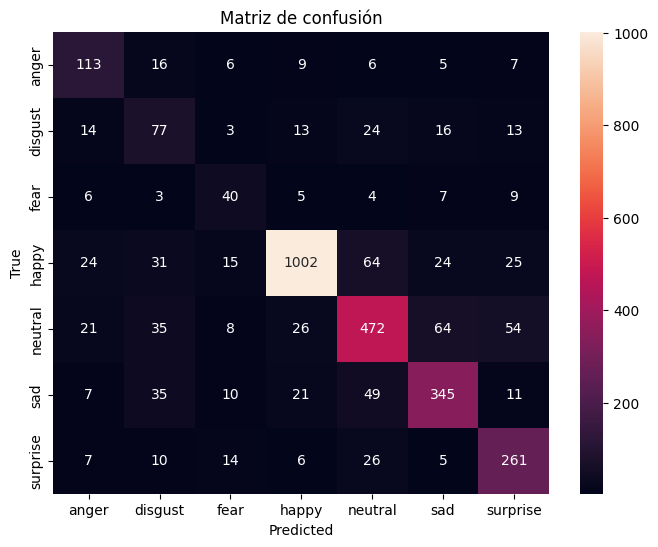

In [19]:
##MATRIZ DE CONFUSION

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de confusión")
plt.show()


In [20]:
##TIEMPO DE INFERENCIA

start = time.time()
aux = model_efficientNetB3.predict(test_ds)
end = time.time()

total_time = end - start
avg_time = total_time / len(X_test)

print(f"Tiempo total de inferencia: {total_time:.4f} s")
print(f"Tiempo por imagen: {avg_time*1000:.4f} ms")


192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Tiempo total de inferencia: 3.8725 s
Tiempo por imagen: 1.2622 ms


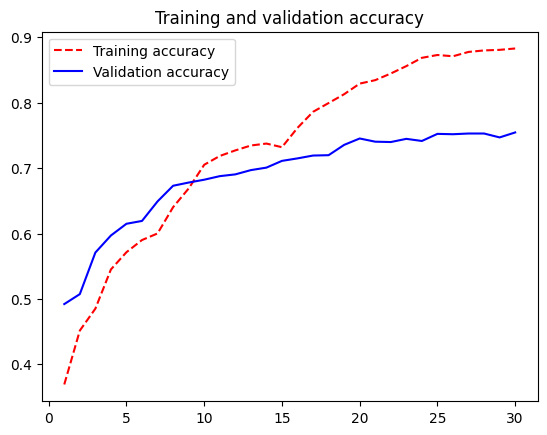

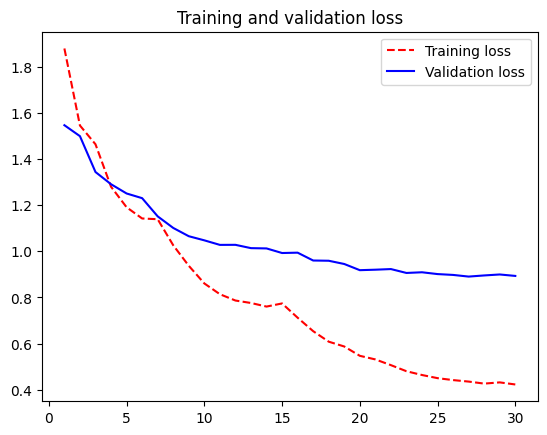

In [21]:
import matplotlib.pyplot as plt

accuracy = history_fase2.history["accuracy"]
val_accuracy = history_fase2.history["val_accuracy"]
loss = history_fase2.history["loss"]
val_loss = history_fase2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [22]:
model_efficientNetB3.save("model_EfficientNetB3Terminado.keras")